In [356]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

%matplotlib inline

In [357]:
words = open('names.txt', 'r').read().splitlines()
words = [word.strip().lower() for word in words]
words[:8]

['ariel',
 'yoneko',
 'abdulai',
 'kayleena',
 'deziah',
 'leone',
 'mauricia',
 'ailah']

In [358]:
len(words)

30274

In [359]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)} #char to int
stoi['.']=0
itos = {i:s for s,i in stoi.items()} #int to char
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [360]:
block_size = 3  #context window size
X, Y = [],[]
print(words[:10])
for w in words[:10]:
    #print('\n')
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X) #dataset 
Y = torch.tensor(Y) #result

print(X.shape)
print(Y.shape)

['ariel', 'yoneko', 'abdulai', 'kayleena', 'deziah', 'leone', 'mauricia', 'ailah', 'dragan', 'titianna']
... ---> a
..a ---> r
.ar ---> i
ari ---> e
rie ---> l
iel ---> .
... ---> y
..y ---> o
.yo ---> n
yon ---> e
one ---> k
nek ---> o
eko ---> .
... ---> a
..a ---> b
.ab ---> d
abd ---> u
bdu ---> l
dul ---> a
ula ---> i
lai ---> .
... ---> k
..k ---> a
.ka ---> y
kay ---> l
ayl ---> e
yle ---> e
lee ---> n
een ---> a
ena ---> .
... ---> d
..d ---> e
.de ---> z
dez ---> i
ezi ---> a
zia ---> h
iah ---> .
... ---> l
..l ---> e
.le ---> o
leo ---> n
eon ---> e
one ---> .
... ---> m
..m ---> a
.ma ---> u
mau ---> r
aur ---> i
uri ---> c
ric ---> i
ici ---> a
cia ---> .
... ---> a
..a ---> i
.ai ---> l
ail ---> a
ila ---> h
lah ---> .
... ---> d
..d ---> r
.dr ---> a
dra ---> g
rag ---> a
aga ---> n
gan ---> .
... ---> t
..t ---> i
.ti ---> t
tit ---> i
iti ---> a
tia ---> n
ian ---> n
ann ---> a
nna ---> .
torch.Size([74, 3])
torch.Size([74])


In [361]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([74, 3]), torch.int64, torch.Size([74]), torch.int64)

In [362]:
C = torch.randn((27, 2))

In [363]:
X.shape, C.shape

(torch.Size([74, 3]), torch.Size([27, 2]))

In [58]:
X[1]

tensor([ 0,  0, 13])

In [ ]:
C[X[1]] #pics an embedding for each charatectar 

tensor([[-1.0224, -0.6120],
        [-1.0224, -0.6120],
        [-0.2865, -0.7022]])

In [83]:
emb = C[X]
emb.shape

torch.Size([13, 3, 2])

In [87]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [88]:
emb.view(-1, 6).shape

torch.Size([13, 6])

In [89]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [90]:
h.shape

torch.Size([13, 100])

In [91]:
W2 = torch.randn(100,27)
b2 = torch.randn(27)

In [92]:
logits = h @ W2 + b2
logits.shape

torch.Size([13, 27])

In [98]:
counts = logits.exp()
prob = counts/counts.sum(1, keepdim=True)

In [99]:
prob.shape

torch.Size([13, 27])

In [110]:
[torch.arange(13),Y] #To get the generated probabilies of actual next cahr

[tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 tensor([13,  1, 14, 15,  0, 13, 25, 20,  8,  9, 12,  9,  0])]

In [108]:
loss = -prob[torch.arange(13),Y].log().mean()
loss

tensor(15.5725)

In [111]:
#---------- To try with multiple parameter --------------

In [364]:
def build_dataset(words):
    block_size = 3  #context window size
    X, Y = [],[]
    for w in words:
        #print('\n')
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]
    X = torch.tensor(X) #dataset 
    Y = torch.tensor(Y) #result
    print(X.shape, Y.shape)
    return X, Y


l1 = int(len(words) * 0.8)
l2 = int(len(words) * 0.9)
Xtrain, Ytrain= build_dataset(words[:l1])
Xdev, Ydev = build_dataset(words[l1:l2])
Xtest, Ytest = build_dataset(words[l2:])



torch.Size([176778, 3]) torch.Size([176778])
torch.Size([22190, 3]) torch.Size([22190])
torch.Size([22267, 3]) torch.Size([22267])


In [365]:
X.shape , Y.shape

(torch.Size([74, 3]), torch.Size([74]))

In [366]:
g = torch.Generator().manual_seed(224783647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]


In [367]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [368]:
for p in parameters:
    p.requires_grad = True

In [369]:
lre = torch.linspace(-3, 0 , 1000)
lrs = 10**lre


In [370]:
lri = []
lossi = []
stepi = []

In [371]:

for i in range(200000):
    #minibactch construct
    ix = torch.randint(0,  Xtrain.shape[0], (128,))
    emb = C[Xtrain[ix]] #13, 3, 2
    h = torch.tanh(emb.view(-1, 30) @ W1 * b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytrain[ix])
    #print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    lr = 0.1 if i< 100000 else 0.01
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
    for p in parameters:
        p.data += -lr * p.grad
print(loss.item())


2.1619973182678223


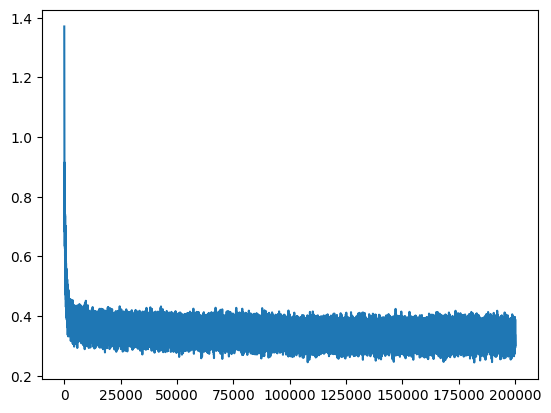

In [372]:
#plt.plot(lri, lossi)
plt.plot(stepi, lossi)

In [373]:
emb = C[Xtrain] #13, 3, 2
h = torch.tanh(emb.view(-1, 30) @ W1 * b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytrain)
print(loss.item())

2.1639716625213623


In [374]:
emb = C[Xdev] #13, 3, 2
h = torch.tanh(emb.view(-1, 30) @ W1 * b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.1902761459350586


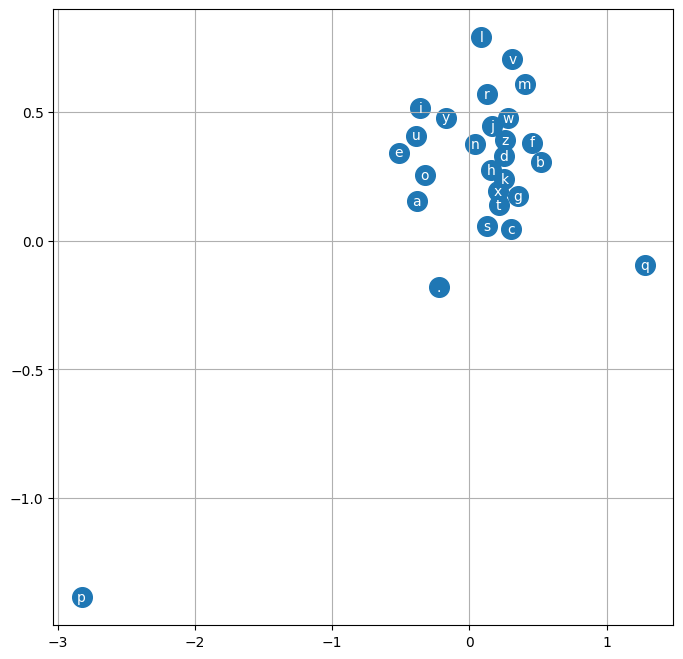

In [ ]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [375]:
# sample from the model
g = torch.Generator().manual_seed(224783647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

ruegra.
ruyprr.
ujjrawr.
ujurwnugwk.
ruyprx.
ruypru.
ruegna.
ruegnx.
rueggbi.
ruypru.
uuegbgkt.
ujuru.
ruyurugwk.
ruyprr.
rueggbdknayxruoggkt.
rujrr.
ruegbg.
rujrr.
ruyprr.
ruypru.
